In [1]:
import hashlib
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from transformers import DistilBertModel

from datasets import Dataset, DatasetDict, load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    DataCollatorWithPadding
)

import torch
from torch import nn

warnings.filterwarnings('ignore')

print("Библиотеки импортированы. CUDA доступен:" , torch.cuda.is_available())

Библиотеки импортированы. CUDA доступен: True


In [2]:
DATASET = "Tobi-Bueck/customer-support-tickets"

def read_idx(path: Path) -> np.ndarray:
    """Читает индексы из текстового файла."""
    arr = np.loadtxt(path, dtype=np.int64)
    return arr

def md5(s: str) -> str:
    """Вычисляет MD5-хеш строки."""
    return hashlib.md5(s.encode("utf-8", errors="ignore")).hexdigest()

def split_df(df: pd.DataFrame, repo_root: Path) -> dict[str, pd.DataFrame]:
    """Разделяет датафрейм на train/val/test по заданным индексам."""
    train_idx = read_idx(repo_root / "data" / "train_idx.txt")
    val_idx = read_idx(repo_root / "data" / "val_idx.txt")
    test_idx = read_idx(repo_root / "data" / "test_idx.txt")

    # Убедимся, что индексы не выходят за пределы
    assert train_idx.max() < len(df), "Индекс train выходит за границы датасета"
    assert val_idx.max() < len(df), "Индекс val выходит за границы датасета"
    assert test_idx.max() < len(df), "Индекс test выходит за границы датасета"

    out = {
        "train": df.iloc[train_idx].copy(),
        "val": df.iloc[val_idx].copy(),
        "test": df.iloc[test_idx].copy(),
    }
    return out

print("Загружаем датасет...")
ds = load_dataset(DATASET)["train"]
df = ds.to_pandas()
print(f"Датасет загружен. Размер: {len(df)} строк.")

# Проверяем наличие необходимых колонок
needed = {"subject", "body", "queue", "priority", "type", "language"}
missing = sorted(list(needed - set(df.columns)))
if missing:
    raise SystemExit(f"В датасете отсутствуют колонки: {missing}")

# Указываем путь к папке data (в Colab она находится в корневой директории)
repo_root = Path("/content")
splits = split_df(df, repo_root)

# Заменяем NaN в 'type' на 'Unknown', как просят в условии
for k in splits:
    splits[k]["type"] = splits[k]["type"].fillna("Unknown")
    # Также заполним NaN в тексте, чтобы избежать ошибок
    splits[k]["subject"] = splits[k]["subject"].fillna("").astype(str)
    splits[k]["body"] = splits[k]["body"].fillna("").astype(str)

print("Данные успешно разделены на train/val/test.")
print(f"Train: {len(splits['train'])} | Val: {len(splits['val'])} | Test: {len(splits['test'])}")

Загружаем датасет...


README.md: 0.00B [00:00, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv: 0.00B [00:00, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

Датасет загружен. Размер: 61765 строк.
Данные успешно разделены на train/val/test.
Train: 49412 | Val: 6176 | Test: 6177



РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ (EDA)

--- РАЗМЕРЫ СПЛИТОВ ---
train: 49412
val: 6176
test: 6177

--- ПРОПУСКИ (доля) ---
train {'subject': 0.0, 'body': 0.0, 'queue': 0.0, 'priority': 0.0, 'type': 0.0, 'language': 0.0}
val {'subject': 0.0, 'body': 0.0, 'queue': 0.0, 'priority': 0.0, 'type': 0.0, 'language': 0.0}
test {'subject': 0.0, 'body': 0.0, 'queue': 0.0, 'priority': 0.0, 'type': 0.0, 'language': 0.0}

--- ДЛИНА ТЕКСТА (subject+body) ---

train:
  символов:  mean=464.8, p50=460, p90=755, max=2285

val:
  символов:  mean=466.7, p50=463, p90=753, max=1678

test:
  символов:  mean=460.3, p50=454, p90=751, max=1516

--- РАСПРЕДЕЛЕНИЕ ЯЗЫКОВ ---
train:
    de: 54.24%
    en: 45.76%
val:
    de: 54.65%
    en: 45.35%
test:
    de: 53.91%
    en: 46.09%

--- РАСПРЕДЕЛЕНИЕ ЦЕЛЕВЫХ ПЕРЕМЕННЫХ ---


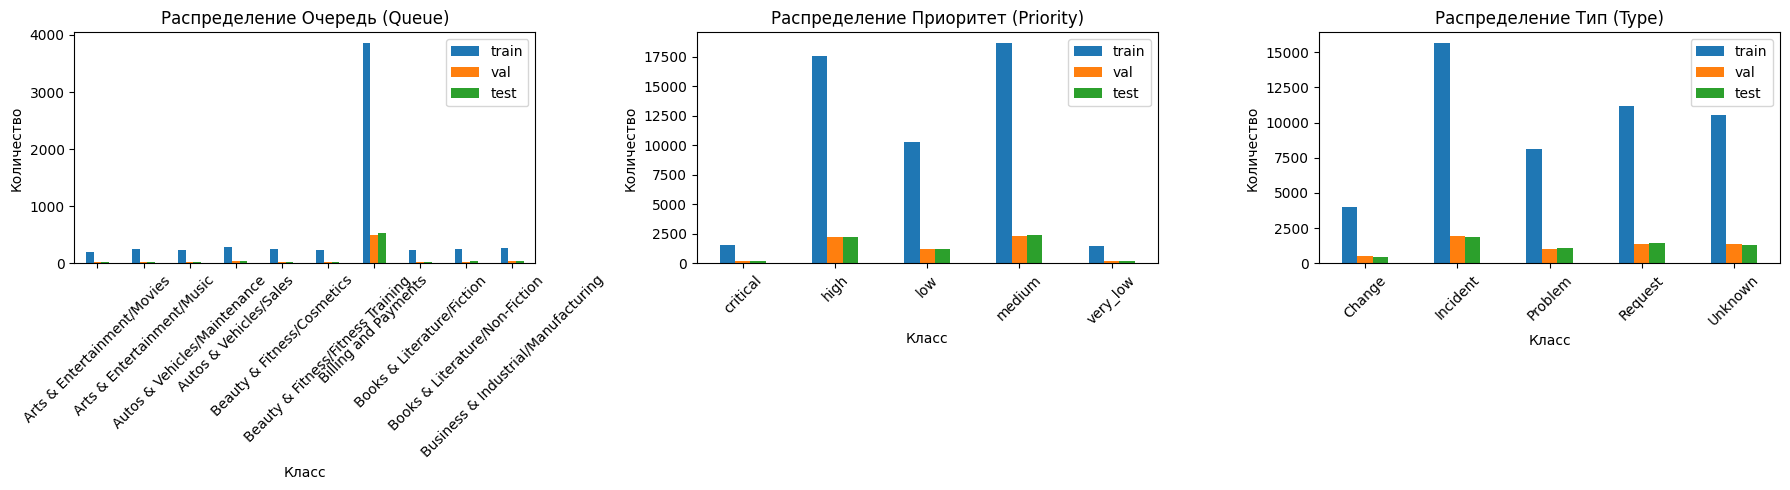


--- ПРОВЕРКА ДУБЛИКАТОВ МЕЖДУ СПЛИТАМИ (MD5 хеш subject+body) ---
train: уникальных хешей 42749/49412 (дубликатов внутри сплита: 13.48%)
val: уникальных хешей 5362/6176 (дубликатов внутри сплита: 13.18%)
test: уникальных хешей 5348/6177 (дубликатов внутри сплита: 13.42%)
Общие хеши: train∩val=0, train∩test=0, val∩test=0
[OK] Пересечений хешей нет.


In [3]:
# Функция из условия, немного дополним ее визуализацией
def basic_eda(splits: dict[str, pd.DataFrame]):
    print("\n" + "="*50)
    print("РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ (EDA)")
    print("="*50)

    print("\n--- РАЗМЕРЫ СПЛИТОВ ---")
    for k, d in splits.items():
        print(f"{k}: {len(d)}")

    print("\n--- ПРОПУСКИ (доля) ---")
    cols = ["subject", "body", "queue", "priority", "type", "language"]
    for k, d in splits.items():
        miss = {c: float(d[c].isna().mean()) for c in cols if c in d.columns}
        print(k, {c: round(miss[c], 4) for c in miss})

    # Длина текста
    print("\n--- ДЛИНА ТЕКСТА (subject+body) ---")
    for k, d in splits.items():
        txt = d["subject"] + "\n\n" + d["body"]
        lens = txt.str.len()
        print(f"\n{k}:")
        print(f"  символов:  mean={lens.mean():.1f}, p50={lens.median():.0f}, p90={lens.quantile(0.9):.0f}, max={lens.max()}")

    # Распределение языков
    print("\n--- РАСПРЕДЕЛЕНИЕ ЯЗЫКОВ ---")
    for k, d in splits.items():
        lang_dist = d["language"].fillna("NA").value_counts(normalize=True)
        print(f"{k}:")
        for lang, prop in lang_dist.items():
            print(f"    {lang}: {prop:.2%}")

    # Распределение таргетов
    print("\n--- РАСПРЕДЕЛЕНИЕ ЦЕЛЕВЫХ ПЕРЕМЕННЫХ ---")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    targets = ['queue', 'priority', 'type']
    titles = ['Очередь (Queue)', 'Приоритет (Priority)', 'Тип (Type)']

    for i, (target, title) in enumerate(zip(targets, titles)):
        train_counts = splits['train'][target].value_counts().sort_index()
        val_counts = splits['val'][target].value_counts().sort_index()
        test_counts = splits['test'][target].value_counts().sort_index()

        # Для queue, покажем только топ-10, чтобы график был читаемым
        if target == 'queue':
            top_10 = train_counts.head(10).index
            train_counts = train_counts[train_counts.index.isin(top_10)]
            val_counts = val_counts[val_counts.index.isin(top_10)]
            test_counts = test_counts[test_counts.index.isin(top_10)]

        df_plot = pd.DataFrame({
            'train': train_counts,
            'val': val_counts,
            'test': test_counts
        }).fillna(0) # заполняем нулями классы, которых нет в сплите

        df_plot.plot(kind='bar', ax=axes[i])
        axes[i].set_title(f'Распределение {title}')
        axes[i].set_xlabel('Класс')
        axes[i].set_ylabel('Количество')
        axes[i].legend(loc='upper right')
        axes[i].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# Запускаем EDA
basic_eda(splits)

# Функция проверки на дубликаты из условия
def duplicate_checks(splits: dict[str, pd.DataFrame]) -> None:
    print("\n--- ПРОВЕРКА ДУБЛИКАТОВ МЕЖДУ СПЛИТАМИ (MD5 хеш subject+body) ---")
    hashes = {}
    for k, d in splits.items():
        txt = d["subject"] + "\n\n" + d["body"]
        h = txt.map(md5)
        hashes[k] = set(h.tolist())
        dup_within = 1.0 - (len(hashes[k]) / len(d))
        print(f"{k}: уникальных хешей {len(hashes[k])}/{len(d)} (дубликатов внутри сплита: {dup_within:.2%})")

    inter_tv = len(hashes["train"] & hashes["val"])
    inter_tt = len(hashes["train"] & hashes["test"])
    inter_vt = len(hashes["val"] & hashes["test"])
    print(f"Общие хеши: train∩val={inter_tv}, train∩test={inter_tt}, val∩test={inter_vt}")

    if inter_tv or inter_tt or inter_vt:
        print("[WARN] Найдены пересечения хешей между сплитами (возможна утечка данных).")
    else:
        print("[OK] Пересечений хешей нет.")

duplicate_checks(splits)


--- БАЗОВАЯ СТАТИСТИКА ---
Количество уникальных классов queue:
  Train: 52
  Val: 52
  Test: 52

Классы, которые есть в train, но отсутствуют в val: 0
Классы, которые есть в train, но отсутствуют в test: 0

--- РАСПРЕДЕЛЕНИЕ КЛАССОВ (ТОП-20) ---

Топ-20 самых частых классов:
                                     Количество      Доля
queue                                                    
Technical Support                         11354  0.229782
Product Support                            7139  0.144479
Customer Service                           5905  0.119505
IT Support                                 4673  0.094572
Billing and Payments                       3853  0.077977
Returns and Exchanges                      1956  0.039586
Service Outages and Maintenance            1534  0.031045
Sales and Pre-Sales                        1228  0.024852
Human Resources                             730  0.014774
General Inquiry                             532  0.010767
News                      

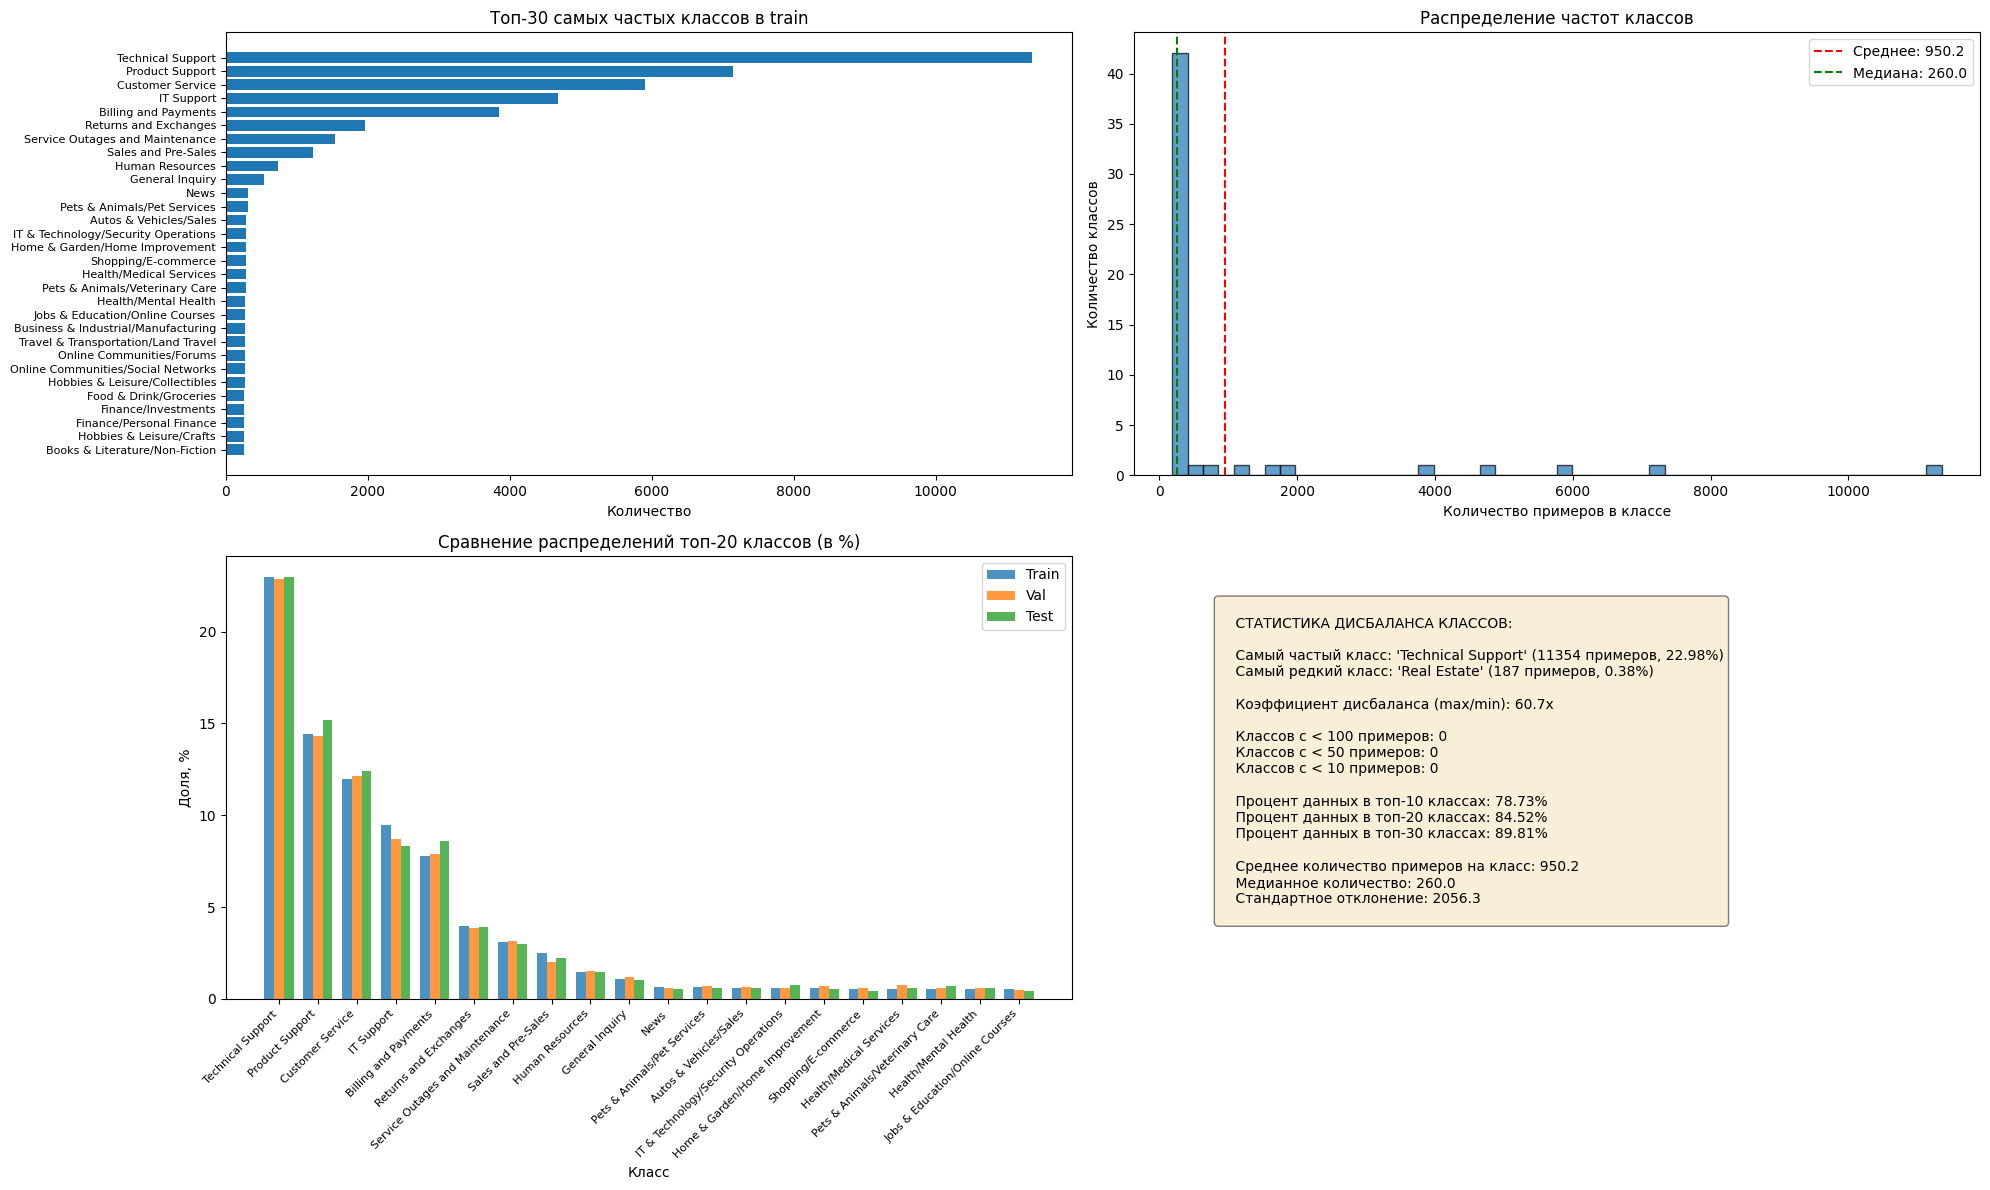


--- СВЯЗЬ QUEUE С ДРУГИМИ ПЕРЕМЕННЫМИ ---

Топ-5 классов queue по распределению priority:

Technical Support:
  high: 58.4%
  medium: 30.0%
  low: 11.6%
  critical: 0.0%
  very_low: 0.0%

Product Support:
  medium: 49.8%
  high: 30.3%
  low: 20.0%
  critical: 0.0%
  very_low: 0.0%

Customer Service:
  medium: 47.3%
  low: 33.5%
  high: 19.2%
  critical: 0.0%
  very_low: 0.0%

IT Support:
  high: 48.7%
  medium: 41.6%
  low: 9.7%
  critical: 0.0%
  very_low: 0.0%

Billing and Payments:
  medium: 48.8%
  high: 29.0%
  low: 22.1%
  critical: 0.0%
  very_low: 0.0%

Топ-5 классов queue по распределению type:

Technical Support:
  Incident: 52.4%
  Problem: 21.5%
  Request: 20.0%
  Change: 6.1%
  Unknown: 0.0%

Product Support:
  Incident: 42.7%
  Problem: 22.8%
  Request: 22.7%
  Change: 11.8%
  Unknown: 0.0%

Customer Service:
  Request: 46.1%
  Incident: 26.1%
  Problem: 20.4%
  Change: 7.3%
  Unknown: 0.0%

IT Support:
  Incident: 36.8%
  Problem: 25.6%
  Request: 20.7%
  Change: 16.9%


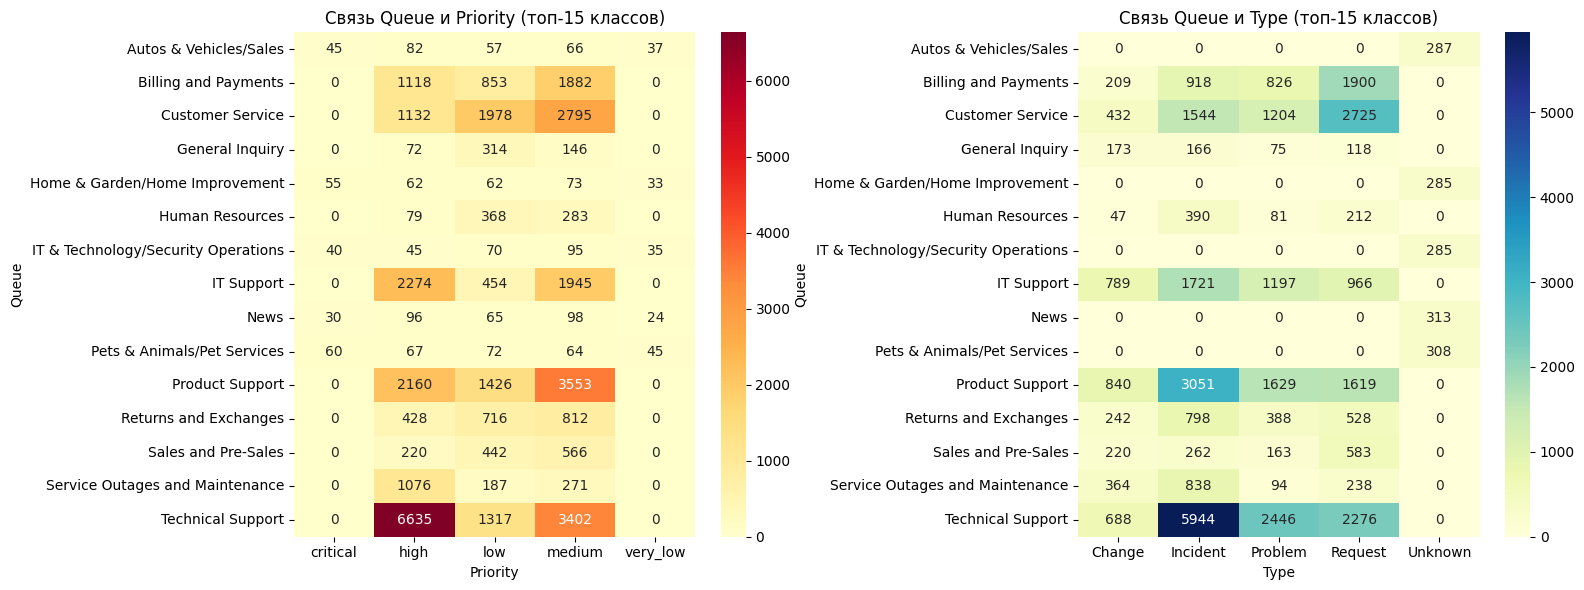

In [4]:
# Расширенный EDA с подробным анализом queue

def detailed_queue_eda(splits: dict[str, pd.DataFrame]):
    """
    Подробный анализ целевой переменной queue
    """
    train_df = splits['train']
    val_df = splits['val']
    test_df = splits['test']

    # 1. Базовая статистика по количеству классов
    print("\n--- БАЗОВАЯ СТАТИСТИКА ---")
    n_classes_train = train_df['queue'].nunique()
    n_classes_val = val_df['queue'].nunique()
    n_classes_test = test_df['queue'].nunique()

    print(f"Количество уникальных классов queue:")
    print(f"  Train: {n_classes_train}")
    print(f"  Val: {n_classes_val}")
    print(f"  Test: {n_classes_test}")

    # Проверяем, все ли классы из train присутствуют в val и test
    train_classes = set(train_df['queue'].unique())
    val_classes = set(val_df['queue'].unique())
    test_classes = set(test_df['queue'].unique())

    missing_in_val = train_classes - val_classes
    missing_in_test = train_classes - test_classes

    print(f"\nКлассы, которые есть в train, но отсутствуют в val: {len(missing_in_val)}")
    if len(missing_in_val) > 0:
        print(f"  Примеры: {sorted(list(missing_in_val))[:10]}")

    print(f"Классы, которые есть в train, но отсутствуют в test: {len(missing_in_test)}")
    if len(missing_in_test) > 0:
        print(f"  Примеры: {sorted(list(missing_in_test))[:10]}")

    # 2. Распределение классов (топ и флоп)
    print("\n--- РАСПРЕДЕЛЕНИЕ КЛАССОВ (ТОП-20) ---")

    class_counts = train_df['queue'].value_counts()
    class_proportions = train_df['queue'].value_counts(normalize=True)

    # Создаем DataFrame для удобства
    dist_df = pd.DataFrame({
        'Количество': class_counts,
        'Доля': class_proportions
    })

    print("\nТоп-20 самых частых классов:")
    print(dist_df.head(20).to_string())

    print("\nТоп-20 самых редких классов:")
    print(dist_df.tail(20).to_string())

    # 3. Визуализация распределения
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))

    # Топ-30 классов в train
    top30 = class_counts.head(30)
    axes[0, 0].barh(range(len(top30)), top30.values)
    axes[0, 0].set_yticks(range(len(top30)))
    axes[0, 0].set_yticklabels(top30.index, fontsize=8)
    axes[0, 0].set_xlabel('Количество')
    axes[0, 0].set_title('Топ-30 самых частых классов в train')
    axes[0, 0].invert_yaxis()

    # Гистограмма распределения частот классов
    axes[0, 1].hist(class_counts.values, bins=50, edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('Количество примеров в классе')
    axes[0, 1].set_ylabel('Количество классов')
    axes[0, 1].set_title('Распределение частот классов')
    axes[0, 1].axvline(x=class_counts.mean(), color='red', linestyle='--', label=f'Среднее: {class_counts.mean():.1f}')
    axes[0, 1].axvline(x=class_counts.median(), color='green', linestyle='--', label=f'Медиана: {class_counts.median():.1f}')
    axes[0, 1].legend()

    # Сравнение распределений в train/val/test для топ-20 классов
    top20_classes = class_counts.head(20).index

    # Нормализуем计数ики для сравнения пропорций
    train_props = (train_df['queue'].value_counts(normalize=True) * 100).loc[top20_classes]
    val_props = (val_df['queue'].value_counts(normalize=True) * 100).reindex(top20_classes, fill_value=0)
    test_props = (test_df['queue'].value_counts(normalize=True) * 100).reindex(top20_classes, fill_value=0)

    x = np.arange(len(top20_classes))
    width = 0.25

    axes[1, 0].bar(x - width, train_props.values, width, label='Train', alpha=0.8)
    axes[1, 0].bar(x, val_props.values, width, label='Val', alpha=0.8)
    axes[1, 0].bar(x + width, test_props.values, width, label='Test', alpha=0.8)
    axes[1, 0].set_xlabel('Класс')
    axes[1, 0].set_ylabel('Доля, %')
    axes[1, 0].set_title('Сравнение распределений топ-20 классов (в %)')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(top20_classes, rotation=45, ha='right', fontsize=8)
    axes[1, 0].legend()

    # Статистика дисбаланса
    axes[1, 1].axis('off')

    stats_text = """
    СТАТИСТИКА ДИСБАЛАНСА КЛАССОВ:

    Самый частый класс: '{}' ({} примеров, {:.2f}%)
    Самый редкий класс: '{}' ({} примеров, {:.2f}%)

    Коэффициент дисбаланса (max/min): {:.1f}x

    Классов с < 100 примеров: {}
    Классов с < 50 примеров: {}
    Классов с < 10 примеров: {}

    Процент данных в топ-10 классах: {:.2f}%
    Процент данных в топ-20 классах: {:.2f}%
    Процент данных в топ-30 классах: {:.2f}%

    Среднее количество примеров на класс: {:.1f}
    Медианное количество: {:.1f}
    Стандартное отклонение: {:.1f}
    """.format(
        class_counts.index[0], class_counts.iloc[0], class_proportions.iloc[0] * 100,
        class_counts.index[-1], class_counts.iloc[-1], class_proportions.iloc[-1] * 100,
        class_counts.iloc[0] / max(class_counts.iloc[-1], 1),
        (class_counts < 100).sum(),
        (class_counts < 50).sum(),
        (class_counts < 10).sum(),
        class_counts.head(10).sum() / len(train_df) * 100,
        class_counts.head(20).sum() / len(train_df) * 100,
        class_counts.head(30).sum() / len(train_df) * 100,
        class_counts.mean(),
        class_counts.median(),
        class_counts.std()
    )

    axes[1, 1].text(0.1, 0.9, stats_text, transform=axes[1, 1].transAxes,
                   fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

    # 4. Анализ связи queue с другими переменными
    print("\n--- СВЯЗЬ QUEUE С ДРУГИМИ ПЕРЕМЕННЫМИ ---")

    # С queue и priority
    queue_priority = pd.crosstab(
        train_df['queue'],
        train_df['priority'],
        normalize='index'
    ) * 100

    print("\nТоп-5 классов queue по распределению priority:")
    for queue in class_counts.head(5).index:
        print(f"\n{queue}:")
        priority_dist = queue_priority.loc[queue].sort_values(ascending=False)
        for priority, pct in priority_dist.head().items():
            print(f"  {priority}: {pct:.1f}%")

    # С queue и type
    queue_type = pd.crosstab(
        train_df['queue'],
        train_df['type'],
        normalize='index'
    ) * 100

    print("\nТоп-5 классов queue по распределению type:")
    for queue in class_counts.head(5).index:
        print(f"\n{queue}:")
        type_dist = queue_type.loc[queue].sort_values(ascending=False)
        for type_name, pct in type_dist.head().items():
            print(f"  {type_name}: {pct:.1f}%")

    # 5. Визуализация связи
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Heatmap для queue-priority (топ-15 классов)
    top15_queues = class_counts.head(15).index
    queue_priority_top15 = pd.crosstab(
        train_df[train_df['queue'].isin(top15_queues)]['queue'],
        train_df[train_df['queue'].isin(top15_queues)]['priority']
    )

    sns.heatmap(queue_priority_top15, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0])
    axes[0].set_title('Связь Queue и Priority (топ-15 классов)')
    axes[0].set_xlabel('Priority')
    axes[0].set_ylabel('Queue')

    # Heatmap для queue-type (топ-15 классов)
    queue_type_top15 = pd.crosstab(
        train_df[train_df['queue'].isin(top15_queues)]['queue'],
        train_df[train_df['queue'].isin(top15_queues)]['type']
    )

    sns.heatmap(queue_type_top15, annot=True, fmt='d', cmap='YlGnBu', ax=axes[1])
    axes[1].set_title('Связь Queue и Type (топ-15 классов)')
    axes[1].set_xlabel('Type')
    axes[1].set_ylabel('Queue')

    plt.tight_layout()
    plt.show()

    return class_counts

# Запускаем подробный анализ queue
queue_distribution = detailed_queue_eda(splits)

In [5]:
def analyze_text_by_queue(splits: dict[str, pd.DataFrame], queue_distribution, top_n=10):
    """
    Анализ текстов для самых частых и самых редких классов queue
    """

    train_df = splits['train']

    # Создаем колонку с полным текстом
    train_df['full_text'] = train_df['subject'] + " " + train_df['body']

    # Топ-N самых частых классов
    top_classes = queue_distribution.head(top_n).index.tolist()
    bottom_classes = queue_distribution.tail(top_n).index.tolist()

    print(f"\n--- АНАЛИЗ ТОП-{top_n} САМЫХ ЧАСТЫХ КЛАССОВ ---")

    for i, queue_class in enumerate(top_classes, 1):
        class_texts = train_df[train_df['queue'] == queue_class]['full_text']

        print(f"\n{i}. {queue_class}")
        print(f"   Количество примеров: {len(class_texts)}")

        # Статистика длин текстов
        text_lengths = class_texts.str.len()
        print(f"   Длина текста (символы):")
        print(f"     Средняя: {text_lengths.mean():.1f}")
        print(f"     Медиана: {text_lengths.median():.1f}")
        print(f"     Std: {text_lengths.std():.1f}")

        # Примеры текстов
        print(f"\n   Примеры текстов:")
        for j, text in enumerate(class_texts.sample(min(3, len(class_texts))).values):
            preview = text[:200] + "..." if len(text) > 200 else text
            print(f"     {j+1}. {preview}")

    print(f"\n--- АНАЛИЗ ТОП-{top_n} САМЫХ РЕДКИХ КЛАССОВ ---")

    for i, queue_class in enumerate(bottom_classes, 1):
        class_texts = train_df[train_df['queue'] == queue_class]['full_text']

        print(f"\n{i}. {queue_class}")
        print(f"   Количество примеров: {len(class_texts)}")

        if len(class_texts) > 0:
            text_lengths = class_texts.str.len()
            print(f"   Длина текста (символы):")
            print(f"     Средняя: {text_lengths.mean():.1f}")
            print(f"     Медиана: {text_lengths.median():.1f}")

            print(f"\n   Примеры текстов:")
            for j, text in enumerate(class_texts.sample(min(3, len(class_texts))).values):
                preview = text[:200] + "..." if len(text) > 200 else text
                print(f"     {j+1}. {preview}")
        else:
            print(f"   Нет примеров в train сплите")

# Запускаем анализ текстов
analyze_text_by_queue(splits, queue_distribution, top_n=5)


--- АНАЛИЗ ТОП-5 САМЫХ ЧАСТЫХ КЛАССОВ ---

1. Technical Support
   Количество примеров: 11354
   Длина текста (символы):
     Средняя: 433.7
     Медиана: 420.0
     Std: 218.4

   Примеры текстов:
     1. Suspicion of Security Breach A potential security incident is suspected due to detected data vulnerabilities. There is a possibility that an internal hacker may have exploited misconfigured security s...
     2. Verbesserung der Unterstützung für Investitionsanalytik in MATLAB Gehörte Kundenservice, wenden Sie sich an mich, um Informationen über die Optimierung der Investitionsanalytikunterstützung in MATLAB ...
     3. Untersuchung eines Datenlecks Sehr geehrter Kundenservice, ich möchte Sie darüber informieren, dass ein Gesundheitsdienstleister möglicherweise gegen datenschutzrechtliche Vorschriften verstoßen hat, ...

2. Product Support
   Количество примеров: 7139
   Длина текста (символы):
     Средняя: 426.9
     Медиана: 409.0
     Std: 221.5

   Примеры текстов:
     1. Assi


--- ОБЩЕЕ РАСПРЕДЕЛЕНИЕ ЯЗЫКОВ В TRAIN ---
          Количество  Доля, %
language                     
de             26799    54.24
en             22613    45.76

--- ТОП-20 ОЧЕРЕДЕЙ ПО КОЛИЧЕСТВУ С РАЗБИВКОЙ ПО ЯЗЫКАМ ---

Топ-20 очередей с разбивкой по языкам:
language                                en     de  Всего  EN_%   DE_%
queue                                                                
Всего                                22613  26799  49412  45.8   54.2
Technical Support                     6570   4784  11354  57.9   42.1
Product Support                       4208   2931   7139  58.9   41.1
Customer Service                      3388   2517   5905  57.4   42.6
IT Support                            2712   1961   4673  58.0   42.0
Billing and Payments                  2303   1550   3853  59.8   40.2
Returns and Exchanges                 1123    833   1956  57.4   42.6
Service Outages and Maintenance        881    653   1534  57.4   42.6
Sales and Pre-Sales                

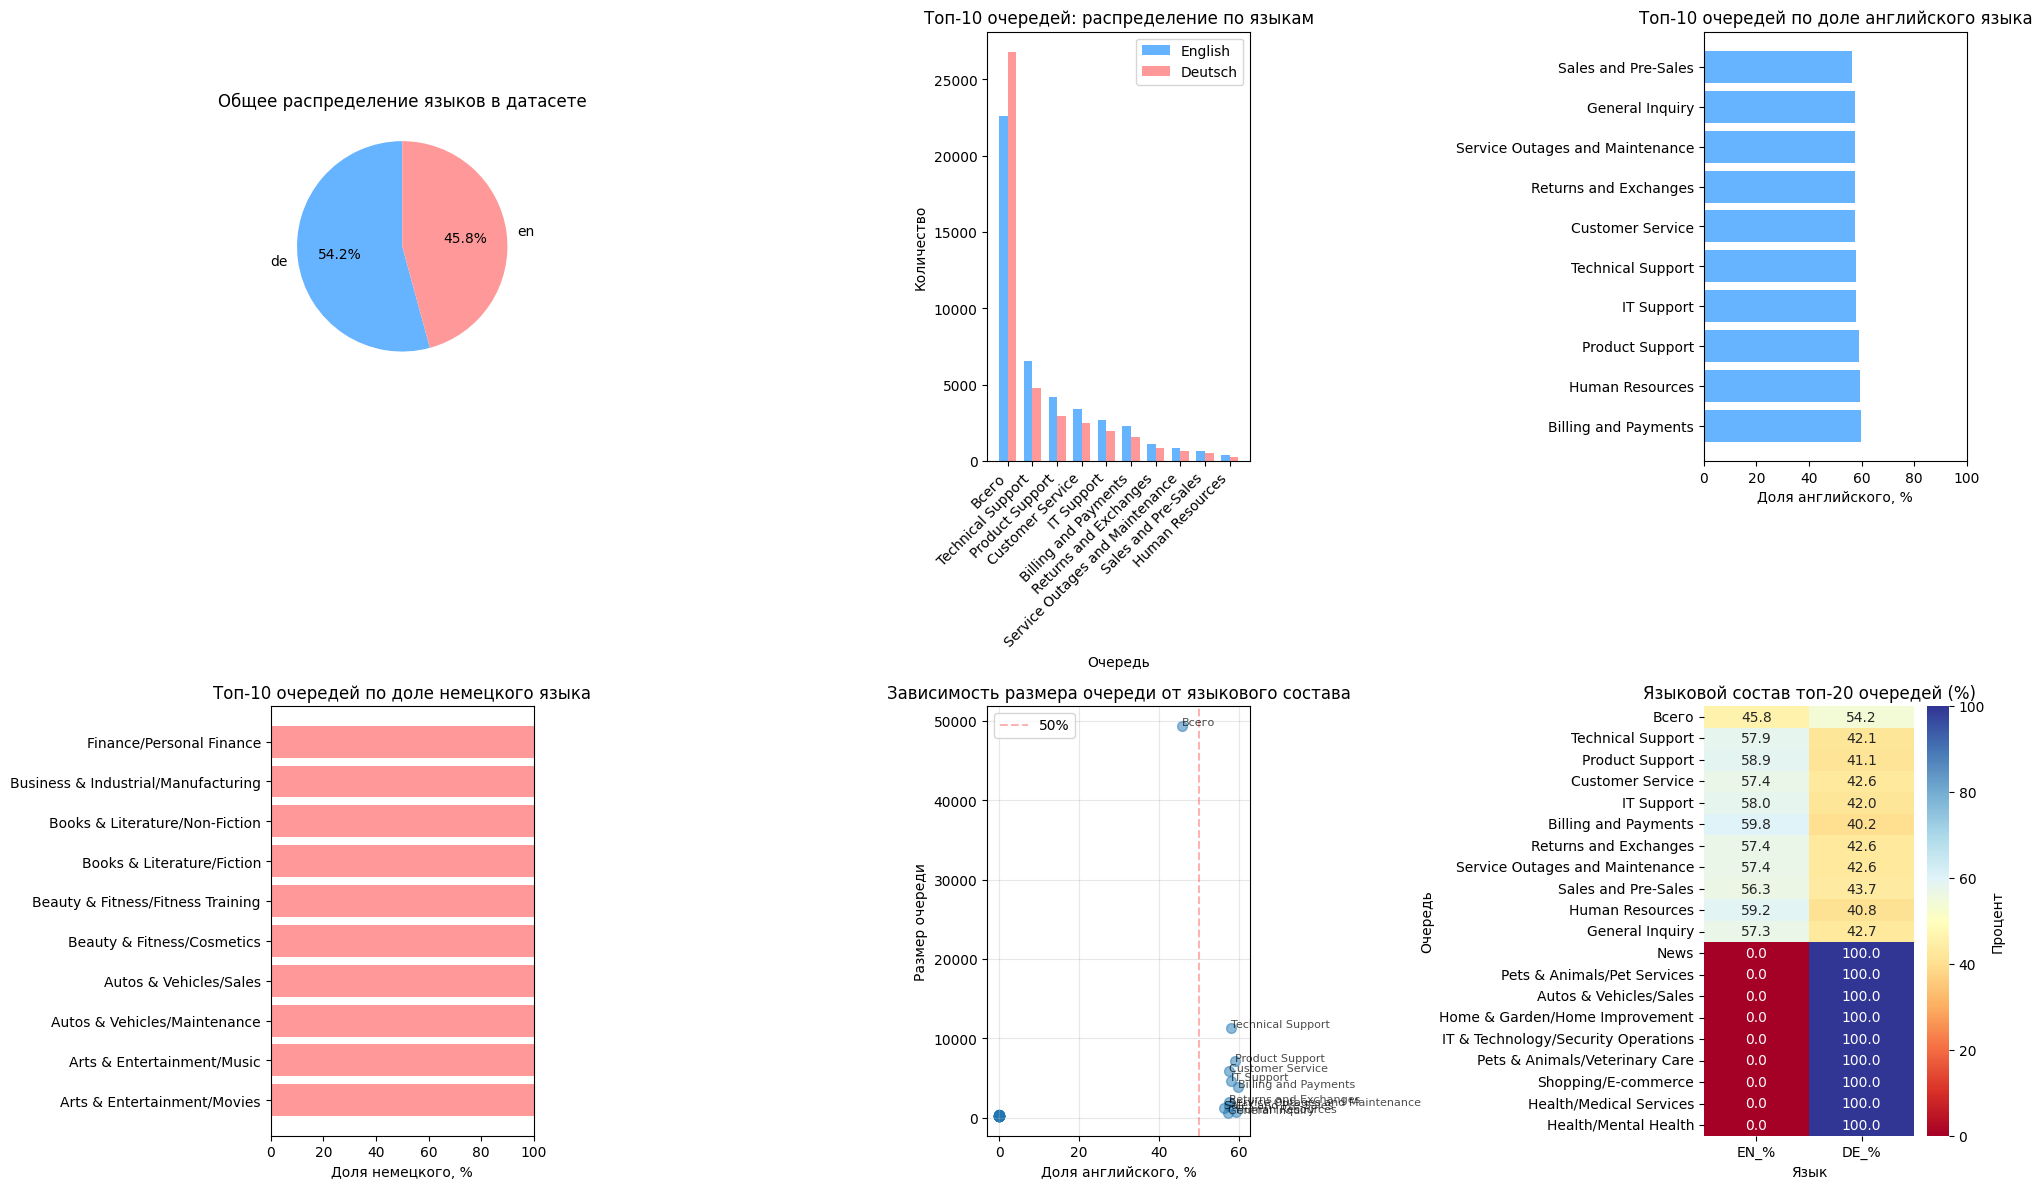


--- ДЕТАЛЬНАЯ СТАТИСТИКА ПО ОЧЕРЕДЯМ ---

Топ-10 очередей с максимальным доминированием английского:
                        Очередь  Всего  EN_%  DE_%  Степень_доминирования
           Billing and Payments   3853  59.8  40.2                   19.5
                Human Resources    730  59.2  40.8                   18.4
                Product Support   7139  58.9  41.1                   17.9
                     IT Support   4673  58.0  42.0                   16.1
              Technical Support  11354  57.9  42.1                   15.7
Service Outages and Maintenance   1534  57.4  42.6                   14.9
               Customer Service   5905  57.4  42.6                   14.8
          Returns and Exchanges   1956  57.4  42.6                   14.8
                General Inquiry    532  57.3  42.7                   14.7
            Sales and Pre-Sales   1228  56.3  43.7                   12.5

Топ-10 очередей с максимальным доминированием немецкого:
                          

In [6]:
def analyze_languages_by_queue(splits: dict[str, pd.DataFrame]):
    """
    Подробный анализ распределения языков по очередям (queue)
    """

    train_df = splits['train'].copy()

    # 1. Общее распределение языков
    print("\n--- ОБЩЕЕ РАСПРЕДЕЛЕНИЕ ЯЗЫКОВ В TRAIN ---")
    lang_dist = train_df['language'].value_counts()
    lang_dist_pct = train_df['language'].value_counts(normalize=True) * 100

    lang_df = pd.DataFrame({
        'Количество': lang_dist,
        'Доля, %': lang_dist_pct.round(2)
    })
    print(lang_df)

    # 2. Топ-20 очередей по количеству и языкам
    print("\n--- ТОП-20 ОЧЕРЕДЕЙ ПО КОЛИЧЕСТВУ С РАЗБИВКОЙ ПО ЯЗЫКАМ ---")

    # Считаем для каждой очереди количество и долю языков
    queue_lang = pd.crosstab(
        train_df['queue'],
        train_df['language'],
        margins=True,
        margins_name='Всего'
    )

    # Добавляем процентные колонки
    queue_lang['EN_%'] = (queue_lang['en'] / queue_lang['Всего'] * 100).round(1)
    queue_lang['DE_%'] = (queue_lang['de'] / queue_lang['Всего'] * 100).round(1)

    # Сортируем по убыванию общего количества и берем топ-20
    top20_queues = queue_lang.sort_values('Всего', ascending=False).head(20)

    print("\nТоп-20 очередей с разбивкой по языкам:")
    print(top20_queues[['en', 'de', 'Всего', 'EN_%', 'DE_%']].to_string())

    # 3. Очереди с преобладанием одного языка
    print("\n--- ОЧЕРЕДИ С ПРЕОБЛАДАНИЕМ ОДНОГО ЯЗЫКА (>90%) ---")

    # Очереди, где >90% английского
    en_dominant = queue_lang[queue_lang['EN_%'] >= 90].sort_values('EN_%', ascending=False)
    if len(en_dominant) > 0:
        print(f"\nОчереди с преобладанием английского (>90%): {len(en_dominant)}")
        print(en_dominant[['en', 'de', 'Всего', 'EN_%', 'DE_%']].to_string())

    # Очереди, где >90% немецкого
    de_dominant = queue_lang[queue_lang['DE_%'] >= 90].sort_values('DE_%', ascending=False)
    if len(de_dominant) > 0:
        print(f"\nОчереди с преобладанием немецкого (>90%): {len(de_dominant)}")
        print(de_dominant[['en', 'de', 'Всего', 'EN_%', 'DE_%']].to_string())

    # 4. Смешанные очереди
    print("\n--- ОЧЕРЕДИ СО СМЕШАННЫМИ ЯЗЫКАМИ (40-60% каждого) ---")
    mixed = queue_lang[(queue_lang['EN_%'] >= 40) & (queue_lang['EN_%'] <= 60)]
    if len(mixed) > 0:
        print(f"Очередей со смешанными языками: {len(mixed)}")
        print(mixed[['en', 'de', 'Всего', 'EN_%', 'DE_%']].sort_values('Всего', ascending=False).head(10).to_string())

    # 5. Визуализация
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))

    # График 1: Общее распределение языков (пирог)
    axes[0, 0].pie(lang_dist.values, labels=lang_dist.index, autopct='%1.1f%%',
                   colors=['#66b3ff', '#ff9999'], startangle=90)
    axes[0, 0].set_title('Общее распределение языков в датасете')

    # График 2: Топ-10 очередей по количеству с разбивкой по языкам (stacked bar)
    top10_for_plot = queue_lang.sort_values('Всего', ascending=False).head(10)

    x = np.arange(len(top10_for_plot))
    width = 0.35

    axes[0, 1].bar(x - width/2, top10_for_plot['en'], width, label='English', color='#66b3ff')
    axes[0, 1].bar(x + width/2, top10_for_plot['de'], width, label='Deutsch', color='#ff9999')

    axes[0, 1].set_xlabel('Очередь')
    axes[0, 1].set_ylabel('Количество')
    axes[0, 1].set_title('Топ-10 очередей: распределение по языкам')
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(top10_for_plot.index, rotation=45, ha='right')
    axes[0, 1].legend()

    # График 3: Топ-10 очередей по доле английского
    top10_en = queue_lang.sort_values('EN_%', ascending=False).head(10)

    axes[0, 2].barh(range(len(top10_en)), top10_en['EN_%'], color='#66b3ff')
    axes[0, 2].set_yticks(range(len(top10_en)))
    axes[0, 2].set_yticklabels(top10_en.index)
    axes[0, 2].set_xlabel('Доля английского, %')
    axes[0, 2].set_title('Топ-10 очередей по доле английского языка')
    axes[0, 2].set_xlim([0, 100])

    # График 4: Топ-10 очередей по доле немецкого
    top10_de = queue_lang.sort_values('DE_%', ascending=False).head(10)

    axes[1, 0].barh(range(len(top10_de)), top10_de['DE_%'], color='#ff9999')
    axes[1, 0].set_yticks(range(len(top10_de)))
    axes[1, 0].set_yticklabels(top10_de.index)
    axes[1, 0].set_xlabel('Доля немецкого, %')
    axes[1, 0].set_title('Топ-10 очередей по доле немецкого языка')
    axes[1, 0].set_xlim([0, 100])

    # График 5: Scatter plot - размер очереди vs языковой баланс
    axes[1, 1].scatter(queue_lang['EN_%'], queue_lang['Всего'], alpha=0.5, s=50)

    # Добавим подписи для крупных очередей
    large_queues = queue_lang[queue_lang['Всего'] > 500]
    for queue in large_queues.index:
        axes[1, 1].annotate(queue, (large_queues.loc[queue, 'EN_%'], large_queues.loc[queue, 'Всего']),
                           fontsize=8, alpha=0.7)

    axes[1, 1].axvline(x=50, color='red', linestyle='--', alpha=0.3, label='50%')
    axes[1, 1].set_xlabel('Доля английского, %')
    axes[1, 1].set_ylabel('Размер очереди')
    axes[1, 1].set_title('Зависимость размера очереди от языкового состава')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    # График 6: Heatmap языкового состава для топ-20 очередей
    top20_for_heatmap = queue_lang.sort_values('Всего', ascending=False).head(20)

    # Создаем матрицу для heatmap (только проценты)
    heatmap_data = top20_for_heatmap[['EN_%', 'DE_%']].copy()

    sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlBu',
                yticklabels=heatmap_data.index, ax=axes[1, 2],
                cbar_kws={'label': 'Процент'})
    axes[1, 2].set_title('Языковой состав топ-20 очередей (%)')
    axes[1, 2].set_xlabel('Язык')
    axes[1, 2].set_ylabel('Очередь')

    plt.tight_layout()
    plt.show()

    # 6. Статистика по языкам для каждой очереди (детальный вывод)
    print("\n--- ДЕТАЛЬНАЯ СТАТИСТИКА ПО ОЧЕРЕДЯМ ---")

    # Создаем сводную таблицу
    summary_stats = []

    for queue in queue_lang.index[:-1]:  # исключаем строку 'Всего'
        queue_data = train_df[train_df['queue'] == queue]

        en_count = (queue_data['language'] == 'en').sum()
        de_count = (queue_data['language'] == 'de').sum()
        total = len(queue_data)

        if total > 0:
            summary_stats.append({
                'Очередь': queue,
                'Всего': total,
                'EN': en_count,
                'DE': de_count,
                'EN_%': round(en_count / total * 100, 1),
                'DE_%': round(de_count / total * 100, 1),
                'Доминирующий_язык': 'EN' if en_count > de_count else 'DE',
                'Степень_доминирования': round(abs(en_count - de_count) / total * 100, 1)
            })

    summary_df = pd.DataFrame(summary_stats)

    # Топ-10 по доминированию английского
    print("\nТоп-10 очередей с максимальным доминированием английского:")
    en_dom = summary_df[summary_df['Доминирующий_язык'] == 'EN'].sort_values('Степень_доминирования', ascending=False).head(10)
    print(en_dom[['Очередь', 'Всего', 'EN_%', 'DE_%', 'Степень_доминирования']].to_string(index=False))

    print("\nТоп-10 очередей с максимальным доминированием немецкого:")
    de_dom = summary_df[summary_df['Доминирующий_язык'] == 'DE'].sort_values('Степень_доминирования', ascending=False).head(10)
    print(de_dom[['Очередь', 'Всего', 'EN_%', 'DE_%', 'Степень_доминирования']].to_string(index=False))

    print("\nТоп-10 самых сбалансированных очередей:")
    balanced = summary_df.sort_values('Степень_доминирования').head(10)
    print(balanced[['Очередь', 'Всего', 'EN_%', 'DE_%', 'Степень_доминирования']].to_string(index=False))

    return summary_df

# Запускаем анализ языков
language_summary = analyze_languages_by_queue(splits)

In [14]:
# Baseline: TF-IDF + Logistic Regression
# Создаем текст для модели
for split in ['train', 'val', 'test']:
    splits[split]['full_text'] = splits[split]['subject'] + "\n\n" + splits[split]['body']

# TF-IDF векторизация
vectorizer = TfidfVectorizer(
    max_features=50000,  # Достаточно для хорошего качества
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9
)

print("Обучение векторайзера...")
X_train = vectorizer.fit_transform(splits['train']['full_text'])
X_val = vectorizer.transform(splits['val']['full_text'])
X_test = vectorizer.transform(splits['test']['full_text'])
print(f"Размерность матрицы признаков: {X_train.shape}")

# Функция для обучения модели
def train_model(X_train, X_val, X_test, y_train, y_val, y_test, task_name):
    """Обучает логистическую регрессию для конкретной задачи"""

    # Для queue используем больше итераций и меньшую регуляризацию
    if task_name == 'queue':
        model = LogisticRegression(
            C=2.0,
            max_iter=2000,
            solver='saga',
            n_jobs=-1,
            random_state=42
        )
    else:
        model = LogisticRegression(
            C=1.0,
            max_iter=1000,
            solver='saga',
            n_jobs=-1,
            random_state=42
        )

    model.fit(X_train, y_train)

    # Предсказания
    pred_val = model.predict(X_val)
    pred_test = model.predict(X_test)

    # Метрики
    acc_val = accuracy_score(y_val, pred_val)
    acc_test = accuracy_score(y_test, pred_test)

    print(f"\n{task_name}:")
    print(f"  Validation Accuracy: {acc_val:.4f}")
    print(f"  Test Accuracy: {acc_test:.4f}")

    if task_name == 'queue':
        f1_val = f1_score(y_val, pred_val, average='macro')
        f1_test = f1_score(y_test, pred_test, average='macro')
        print(f"  Validation Macro F1: {f1_val:.4f}")
        print(f"  Test Macro F1: {f1_test:.4f}")
        return {'acc': acc_test, 'f1': f1_test}
    else:
        return {'acc': acc_test}

# Словарь для сохранения результатов
baseline_results = {}

print("\n--- Обучение моделей ---")
for target in ['queue', 'priority', 'type']:
    y_train = splits['train'][target].astype(str)
    y_val = splits['val'][target].astype(str)
    y_test = splits['test'][target].astype(str)

    baseline_results[target] = train_model(
        X_train, X_val, X_test,
        y_train, y_val, y_test,
        target
    )

# Итоговый скор
final_score_baseline = (
    0.70 * baseline_results['queue']['f1'] +
    0.15 * baseline_results['priority']['acc'] +
    0.15 * baseline_results['type']['acc']
)

print(f"Queue Macro F1: {baseline_results['queue']['f1']:.4f}")
print(f"Priority Accuracy: {baseline_results['priority']['acc']:.4f}")
print(f"Type Accuracy: {baseline_results['type']['acc']:.4f}")
print(f"Score = {final_score_baseline:.4f}")
print("="*50)

Обучение векторайзера...
Размерность матрицы признаков: (49412, 50000)

--- Обучение моделей ---

queue:
  Validation Accuracy: 0.6044
  Test Accuracy: 0.5988
  Validation Macro F1: 0.8025
  Test Macro F1: 0.7830

priority:
  Validation Accuracy: 0.6469
  Test Accuracy: 0.6390

type:
  Validation Accuracy: 0.8706
  Test Accuracy: 0.8711
Queue Macro F1: 0.7830
Priority Accuracy: 0.6390
Type Accuracy: 0.8711
Score = 0.7746


In [7]:
for split in ['train', 'val', 'test']:
    splits[split]['full_text'] = splits[split]['subject'] + "\n\n" + splits[split]['body']
    print(f"Создана колонка full_text для {split}: {len(splits[split])} строк")
# Создаем маппинги для лейблов
label_mappings = {
    'queue': {
        'num_labels': 52,
        'label2id': {label: i for i, label in enumerate(sorted(splits['train']['queue'].unique()))},
        'id2label': {i: label for i, label in enumerate(sorted(splits['train']['queue'].unique()))}
    },
    'priority': {
        'num_labels': 5,
        'label2id': {label: i for i, label in enumerate(sorted(splits['train']['priority'].unique()))},
        'id2label': {i: label for i, label in enumerate(sorted(splits['train']['priority'].unique()))}
    },
    'type': {
        'num_labels': 5,
        'label2id': {label: i for i, label in enumerate(sorted(splits['train']['type'].unique()))},
        'id2label': {i: label for i, label in enumerate(sorted(splits['train']['type'].unique()))}
    }
}

# Создаем Dataset в формате Hugging Face
def prepare_dataset(splits_dict, label_mappings):
    hf_dataset = {}
    for split_name, df in splits_dict.items():
        data = {
            'text': df['full_text'].tolist(),
            'labels_queue': df['queue'].map(label_mappings['queue']['label2id']).tolist(),
            'labels_priority': df['priority'].map(label_mappings['priority']['label2id']).tolist(),
            'labels_type': df['type'].map(label_mappings['type']['label2id']).tolist()
        }
        hf_dataset[split_name] = Dataset.from_dict(data)
    return DatasetDict(hf_dataset)

dataset = prepare_dataset(splits, label_mappings)

# Токенизация (используем мультиязычную модель из-за EN/DE)
model_name = "distilbert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        max_length=256,
        padding=False
    )

print("Токенизация данных...")
tokenized_dataset = dataset.map(tokenize_function, batched=True)
print("Токенизация завершена")

Создана колонка full_text для train: 49412 строк
Создана колонка full_text для val: 6176 строк
Создана колонка full_text для test: 6177 строк


config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Токенизация данных...


Map:   0%|          | 0/49412 [00:00<?, ? examples/s]

Map:   0%|          | 0/6176 [00:00<?, ? examples/s]

Map:   0%|          | 0/6177 [00:00<?, ? examples/s]

Токенизация завершена


In [8]:
# Мультизадачная модель

class MultitaskDistilBERT(nn.Module):
    """Мультизадачная модель на основе DistilBERT"""

    def __init__(self, model_name, num_labels_queue, num_labels_priority, num_labels_type):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(0.3)
        self.hidden_size = self.bert.config.hidden_size

        # Три классификационные головы
        self.classifier_queue = nn.Linear(self.hidden_size, num_labels_queue)
        self.classifier_priority = nn.Linear(self.hidden_size, num_labels_priority)
        self.classifier_type = nn.Linear(self.hidden_size, num_labels_type)

    def forward(self, input_ids=None, attention_mask=None,
                labels_queue=None, labels_priority=None, labels_type=None):

        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.last_hidden_state[:, 0]  # [CLS] токен
        pooled = self.dropout(pooled)

        logits_queue = self.classifier_queue(pooled)
        logits_priority = self.classifier_priority(pooled)
        logits_type = self.classifier_type(pooled)

        loss = None
        if labels_queue is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits_queue, labels_queue)
            loss += loss_fct(logits_priority, labels_priority)
            loss += loss_fct(logits_type, labels_type)

        return {
            'loss': loss,
            'logits_queue': logits_queue,
            'logits_priority': logits_priority,
            'logits_type': logits_type
        }

# Инициализация модели
model = MultitaskDistilBERT(
    model_name,
    num_labels_queue=52,
    num_labels_priority=5,
    num_labels_type=5
)

print(f"\nМодель создана:")
print(f"  Queue классов: 52")
print(f"  Priority классов: 5")
print(f"  Type классов: 5")



model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Модель создана:
  Queue классов: 52
  Priority классов: 5
  Type классов: 5


In [9]:
# Коллатор данных

class MultitaskDataCollator:
    """Кастомный коллатор для мультизадачной модели"""

    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def __call__(self, features):
        batch = {}

        # Паддинг для input_ids и attention_mask
        for key in ['input_ids', 'attention_mask']:
            if key in features[0]:
                # Находим максимальную длину в батче
                max_len = max(len(f[key]) for f in features)
                # Паддим все до max_len
                padded = []
                for f in features:
                    pad_len = max_len - len(f[key])
                    if key == 'input_ids':
                        padded.append(f[key] + [self.tokenizer.pad_token_id] * pad_len)
                    else:
                        padded.append(f[key] + [0] * pad_len)
                batch[key] = torch.tensor(padded)

        # Лейблы просто собираем в тензор
        for key in ['labels_queue', 'labels_priority', 'labels_type']:
            if key in features[0]:
                batch[key] = torch.tensor([f[key] for f in features], dtype=torch.long)

        return batch

data_collator = MultitaskDataCollator(tokenizer)

def compute_metrics(eval_pred):
    """Вычисление метрик для валидации"""
    predictions = eval_pred.predictions
    labels = eval_pred.label_ids

    # Распаковываем предсказания (3 задачи)
    if isinstance(predictions, tuple):
        logits_queue, logits_priority, logits_type = predictions
    else:
        # Если не кортеж, предполагаем что это массив и пытаемся разделить
        logits_queue = predictions[0]
        logits_priority = predictions[1]
        logits_type = predictions[2]

    # Распаковываем лейблы
    if isinstance(labels, tuple):
        labels_queue, labels_priority, labels_type = labels
    else:
        labels_queue = labels[0]
        labels_priority = labels[1]
        labels_type = labels[2]

    preds_queue = np.argmax(logits_queue, axis=1)
    preds_priority = np.argmax(logits_priority, axis=1)
    preds_type = np.argmax(logits_type, axis=1)

    return {
        'acc_queue': accuracy_score(labels_queue, preds_queue),
        'f1_queue': f1_score(labels_queue, preds_queue, average='macro'),
        'acc_priority': accuracy_score(labels_priority, preds_priority),
        'acc_type': accuracy_score(labels_type, preds_type)
    }

In [10]:
# Обучение трансформера

from transformers import TrainingArguments, Trainer

# Исправляем аргументы обучения (убираем устаревшие параметры)
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=500,  # вместо warmup_ratio
    weight_decay=0.01,
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    report_to='none',
    dataloader_num_workers=2,
    remove_unused_columns=False,
    logging_dir='./logs'  # убираем предупреждение, но оставляем
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    data_collator=data_collator,
    compute_metrics=compute_metrics
    # tokenizer убираем - он не нужен в Trainer
)

trainer.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Acc Queue,F1 Queue,Acc Priority,Acc Type
1,2.638527,2.527849,0.520887,0.742828,0.571891,0.852494
2,2.185018,2.259976,0.567681,0.835952,0.622895,0.875486
3,1.759424,2.199097,0.602979,0.860341,0.651069,0.880991


TrainOutput(global_step=9267, training_loss=2.491743790649269, metrics={'train_runtime': 1364.9112, 'train_samples_per_second': 108.605, 'train_steps_per_second': 6.789, 'total_flos': 0.0, 'train_loss': 2.491743790649269, 'epoch': 3.0})

In [11]:
# Оценка на тесте

test_results = trainer.predict(tokenized_dataset['test'])

# Извлекаем метрики
f1_queue_test = test_results.metrics['test_f1_queue']
acc_queue_test = test_results.metrics['test_acc_queue']
acc_priority_test = test_results.metrics['test_acc_priority']
acc_type_test = test_results.metrics['test_acc_type']

final_score_bert = (
    0.70 * f1_queue_test +
    0.15 * acc_priority_test +
    0.15 * acc_type_test
)

print(f"Queue Macro F1: {f1_queue_test:.4f}")
print(f"Queue Accuracy: {acc_queue_test:.4f}")
print(f"Priority Accuracy: {acc_priority_test:.4f}")
print(f"Type Accuracy: {acc_type_test:.4f}")
print(f"\nИТОГОВЫЙ СКОР: {final_score_bert:.4f}")

Queue Macro F1: 0.8586
Queue Accuracy: 0.6085
Priority Accuracy: 0.6400
Type Accuracy: 0.8828

ИТОГОВЫЙ СКОР: 0.8294


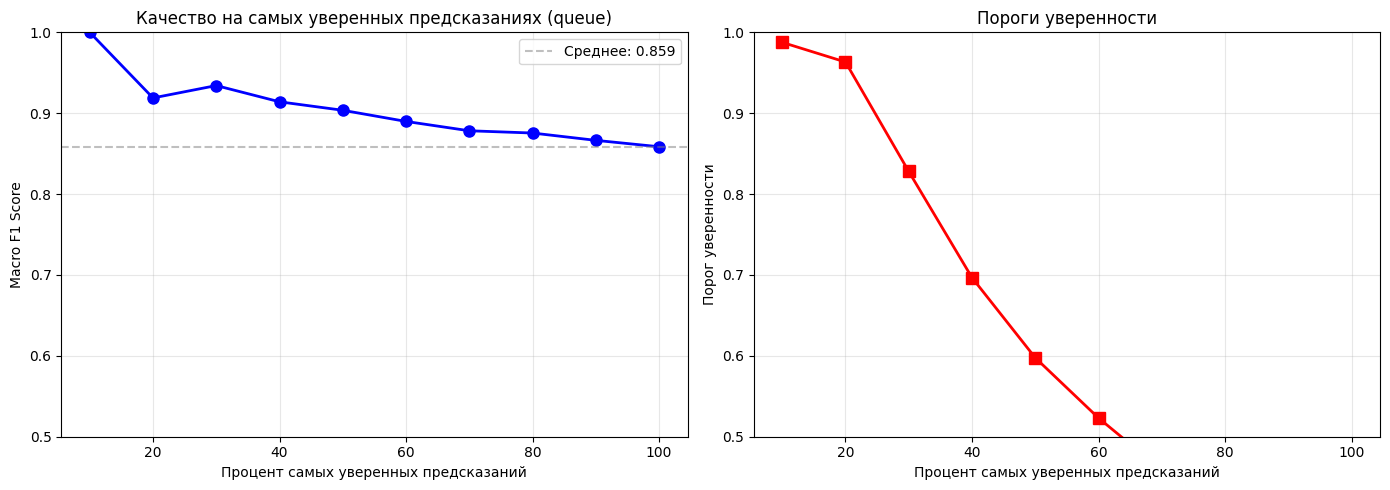


АНАЛИЗ УВЕРЕННОСТИ ДЛЯ QUEUE
    % данных |     Macro F1 |     Accuracy |        Порог |  На человека
----------------------------------------------------------------------------
          10% |       1.0000 |       1.0000 |       0.9876 |           90%
          20% |       0.9189 |       0.9927 |       0.9633 |           80%
          30% |       0.9342 |       0.9606 |       0.8280 |           70%
          40% |       0.9141 |       0.8927 |       0.6967 |           60%
          50% |       0.9036 |       0.8329 |       0.5976 |           50%
          60% |       0.8898 |       0.7790 |       0.5232 |           40%
          70% |       0.8783 |       0.7236 |       0.4586 |           30%
          80% |       0.8755 |       0.6823 |       0.3977 |           20%
          90% |       0.8664 |       0.6433 |       0.3376 |           10%
         100% |       0.8586 |       0.6085 |       0.0989 |            0%


In [12]:
# Анализ уверенности модели

# Получаем вероятности для queue
logits_queue = test_results.predictions[0]
probs = torch.softmax(torch.from_numpy(logits_queue), dim=-1).numpy()
confidences = np.max(probs, axis=1)
preds = np.argmax(logits_queue, axis=1)
true = test_results.label_ids[0]

# Сортируем по уверенности
sorted_idx = np.argsort(-confidences)
conf_sorted = confidences[sorted_idx]
pred_sorted = preds[sorted_idx]
true_sorted = true[sorted_idx]

# Считаем метрики для разных порогов
thresholds = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
f1_scores = []
acc_scores = []
conf_thresholds = []

for p in thresholds:
    n_samples = int(len(conf_sorted) * p / 100)
    if n_samples == 0:
        continue

    pred_subset = pred_sorted[:n_samples]
    true_subset = true_sorted[:n_samples]

    f1 = f1_score(true_subset, pred_subset, average='macro')
    acc = accuracy_score(true_subset, pred_subset)
    f1_scores.append(f1)
    acc_scores.append(acc)
    conf_thresholds.append(conf_sorted[n_samples-1])

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График F1
ax1.plot(thresholds, f1_scores, 'o-', linewidth=2, markersize=8, color='blue')
ax1.axhline(y=f1_queue_test, color='gray', linestyle='--', alpha=0.5, label=f'Среднее: {f1_queue_test:.3f}')
ax1.set_xlabel('Процент самых уверенных предсказаний')
ax1.set_ylabel('Macro F1 Score')
ax1.set_title('Качество на самых уверенных предсказаниях (queue)')
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0.5, 1.0])
ax1.legend()

# График порогов
ax2.plot(thresholds, conf_thresholds, 's-', linewidth=2, markersize=8, color='red')
ax2.set_xlabel('Процент самых уверенных предсказаний')
ax2.set_ylabel('Порог уверенности')
ax2.set_title('Пороги уверенности')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0.5, 1.0])

plt.tight_layout()
plt.show()

# Таблица результатов
print("\n" + "="*60)
print("АНАЛИЗ УВЕРЕННОСТИ ДЛЯ QUEUE")
print("="*60)
print(f"{'% данных':>12} | {'Macro F1':>12} | {'Accuracy':>12} | {'Порог':>12} | {'На человека':>12}")
print("-" * 76)

for p, f, a, t in zip(thresholds, f1_scores, acc_scores, conf_thresholds):
    manual = 100 - p
    print(f"{p:>12}% | {f:>12.4f} | {a:>12.4f} | {t:>12.4f} | {manual:>12}%")



In [15]:
# Сравнение с baseline

print("\n" + "="*60)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("="*60)

print(f"\nBaseline (TF-IDF + Logistic Regression):")
print(f"  Queue Macro F1: {baseline_results['queue']['f1']:.4f}")
print(f"  Priority Accuracy: {baseline_results['priority']['acc']:.4f}")
print(f"  Type Accuracy: {baseline_results['type']['acc']:.4f}")
print(f"  Score: {final_score_baseline:.4f}")

print(f"\nТрансформер (DistilBERT multilingual):")
print(f"  Queue Macro F1: {f1_queue_test:.4f}")
print(f"  Priority Accuracy: {acc_priority_test:.4f}")
print(f"  Type Accuracy: {acc_type_test:.4f}")
print(f"  Score: {final_score_bert:.4f}")

improvement = (final_score_bert - final_score_baseline) / final_score_baseline * 100
print(f"\nУлучшение: {improvement:+.1f}%")


СРАВНЕНИЕ РЕЗУЛЬТАТОВ

Baseline (TF-IDF + Logistic Regression):
  Queue Macro F1: 0.7830
  Priority Accuracy: 0.6390
  Type Accuracy: 0.8711
  Score: 0.7746

Трансформер (DistilBERT multilingual):
  Queue Macro F1: 0.8586
  Priority Accuracy: 0.6400
  Type Accuracy: 0.8828
  Score: 0.8294

Улучшение: +7.1%


In [16]:
# Практические выводы

# Находим оптимальный порог для гибридной системы
optimal_idx = 6  # 70%
optimal_f1 = f1_scores[optimal_idx]
optimal_threshold = conf_thresholds[optimal_idx]
auto_percent = thresholds[optimal_idx]
manual_percent = 100 - auto_percent

print(f"""
1. Базовая модель (полная автоматизация):
   - Macro F1 = {f1_queue_test:.4f}
   - Обрабатываются 100% тикетов

2. Гибридная система (авто + человек):
   - Автоматически обрабатываем {auto_percent}% самых уверенных тикетов
   - Оставшиеся {manual_percent}% отправляем человеку
   - Качество на авто-части: Macro F1 = {optimal_f1:.4f}
   - Порог уверенности: {optimal_threshold:.3f}

3. Эффект:
   - Экономия ручного труда: {auto_percent}%
   - Качество на авто-части: {optimal_f1:.4f} (против {f1_queue_test:.4f} на всех данных)
   - Улучшение качества на авто-части: {(optimal_f1 - f1_queue_test)/f1_queue_test*100:+.1f}%

4. Рекомендация:
   Внедрить гибридную систему с порогом {optimal_threshold:.3f}:
   - Если max(prob) >= {optimal_threshold:.3f} → автоматическая маршрутизация
   - Иначе → отправка на ручную обработку
""")


1. Базовая модель (полная автоматизация):
   - Macro F1 = 0.8586
   - Обрабатываются 100% тикетов

2. Гибридная система (авто + человек):
   - Автоматически обрабатываем 70% самых уверенных тикетов
   - Оставшиеся 30% отправляем человеку
   - Качество на авто-части: Macro F1 = 0.8783
   - Порог уверенности: 0.459

3. Эффект:
   - Экономия ручного труда: 70%
   - Качество на авто-части: 0.8783 (против 0.8586 на всех данных)
   - Улучшение качества на авто-части: +2.3%

4. Рекомендация:
   Внедрить гибридную систему с порогом 0.459:
   - Если max(prob) >= 0.459 → автоматическая маршрутизация
   - Иначе → отправка на ручную обработку

